In [1]:
#NLP - Natural Language Processing

#WhatsApp Chat Pre - Processing

In [2]:
#1.IMPORTING LIBRARIES

import pandas as pd
# import → Python keyword that brings the specified module into the current program
# pandas → Python library used for data manipulation and analysis, especially with tables (DataFrames)
# as → Python keyword used to give an imported item a shorter alias/nickname
# pd → The alias assigned to pandas, used to call the library more easily in code

# This cell imports the pandas library (as pd) for handling and analyzing tabular data.

In [3]:
#2.LOADING THE DATASET

df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip', encoding='utf8')
# df → Variable storing the loaded dataset
# pd.read_csv → Function that reads a CSV/text file and loads it into a DataFrame
# "mabel.txt" → Name of the file being read
# header=None → Tells pandas the file has no header row, so it assigns default numeric column names
# on_bad_lines='skip' → Skips rows that cause parsing errors instead of stopping the whole read (replaces the older error_bad_lines)
# encoding='utf8' → Specifies the text encoding used to read the file

# This cell loads mabel.txt into a DataFrame called df, skipping any malformed rows, using the pandas 2.0+ compatible syntax.

In [4]:
#3.PARSING WHATSAPP-STYLE CHAT DATA

df = df.drop(0)
# df → Variable storing the dataset (reassigned to the dropped version)
# df.drop(0) → Removes the row at index 0 (likely a header or junk first line)

df.columns = ['Date','Chat']
# df.columns → Sets the column names for df
# ['Date','Chat'] → Assigns "Date" to the first column and "Chat" to the second

Message = df["Chat"].str.split("-",n=1,expand=True)
# Message → Variable storing the split result
# df["Chat"] → Selects the "Chat" column
# .str.split("-",n=1,expand=True) → Splits each entry at the first "-" only, returning separate columns instead of a list

df["Time"] = Message[0]
# df["Time"] → Creates a new "Time" column in df
# Message[0] → The first part of the split (text before the "-")

Message1 = Message[1].str.split(":",n=1,expand=True)
# Message1 → Variable storing the further split result
# Message[1] → The second part of the earlier split (text after the "-")
# .str.split(":",n=1,expand=True) → Splits that text at the first ":" only, returning separate columns

df["Name"] = Message1[0]
# df["Name"] → Creates a new "Name" column in df
# Message1[0] → The first part of the second split (text before the ":")

df["Chat"] = Message1[1]
# df["Chat"] → Overwrites the "Chat" column
# Message1[1] → The second part of the second split (text after the ":", the actual message)

df = df[["Date","Time","Name","Chat"]]
# df → Variable storing the reordered DataFrame
# df[[...]] → Selects and reorders columns into Date, Time, Name, Chat

df
# df → Displays the final cleaned and structured DataFrame

# This cell splits the raw "Chat" column into separate Date, Time, Name, and Chat columns for structured chat data.

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [5]:
#4.VIEWING DATASET INFO

df.info()
# df.info → Method that displays a summary of the DataFrame
# () → Calls the method with no extra arguments — shows column names, data types, non-null counts, and memory usage

# This cell prints a structural overview of df, useful for checking data types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    50 non-null     object
 1   Time    50 non-null     object
 2   Name    50 non-null     object
 3   Chat    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB


In [6]:
#!pip install nltk

In [7]:
#5.INSTALLING & IMPORTING SENTIMENT ANALYZER

import nltk
# import → Python keyword that brings the specified module into the current program
# nltk → Natural Language Toolkit; library for text processing and NLP tasks

nltk.download('vader_lexicon')
# nltk.download → Method that downloads NLTK's required data files
# 'vader_lexicon' → The pre-built sentiment word list that VADER needs to score text

from nltk.sentiment.vader import SentimentIntensityAnalyzer
# from → Python keyword used to import specific parts from a library
# nltk.sentiment.vader → Module in NLTK containing the VADER sentiment analysis tool
# import → Brings the specified class into the current program
# SentimentIntensityAnalyzer → Class that scores text for sentiment (positive, negative, neutral, compound)

# This cell installs the VADER lexicon and imports SentimentIntensityAnalyzer for scoring chat message sentiment.

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bkann\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [8]:
#6.CREATING A COPY OF THE DATASET

dataset = df
# dataset → Variable storing a reference to df
# = → Assignment operator; points dataset to the same data as df

# This cell assigns df to dataset for use in the following steps.

In [9]:
#7.REMOVING MISSING VALUES

dataset.dropna(inplace=True)
# dataset.dropna → Method that removes rows containing missing (NaN) values
# inplace=True → Applies the change directly to dataset instead of returning a new copy

# This cell removes any rows with missing values from dataset.

In [10]:
#8.INITIALIZING SENTIMENT ANALYZER

sid = SentimentIntensityAnalyzer()
# sid → Variable storing the sentiment analyzer object
# SentimentIntensityAnalyzer() → Creates a new instance of the VADER sentiment analyzer

# This cell initializes sid, the VADER analyzer used to score sentiment of chat messages.

In [11]:
#9.SCORING SENTIMENT OF A SINGLE MESSAGE

senti = sid.polarity_scores(dataset['Chat'][4])
# senti → Variable storing the sentiment scores
# sid.polarity_scores → Method that analyzes text and returns sentiment scores (positive, negative, neutral, compound)
# dataset['Chat'][4] → Selects the "Chat" text at row index 4

# This cell scores the sentiment of the 5th chat message (index 4) and stores the result in senti.

In [12]:
#10.VIEWING SENTIMENT SCORES

senti
# senti → Displays the sentiment scores dictionary (neg, neu, pos, compound) for the selected chat message

# This cell outputs senti to review the sentiment breakdown of the message.

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

In [13]:
#11.DEFINING SENTIMENT ANALYSIS FUNCTION

def sentimentalAnalysis(data,columnname):
# def → Python keyword used to define a new function
# sentimentalAnalysis → Name of the function being defined
# (data,columnname) → Parameters the function accepts — data (the dataset) and columnname (the text column to analyze)
# : → Marks the start of the function's code block

    #downloading vader_lexicon for the process
    # → Comment describing the purpose of the next imports

    import matplotlib.pyplot as plt
    # import → Python keyword that brings the specified module into the current program
    # matplotlib.pyplot → Module used for creating plots and visualizations
    # as → Python keyword used to give an imported item a shorter alias/nickname
    # plt → The alias assigned to matplotlib.pyplot

    import seaborn as sns
    # import → Python keyword that brings the specified module into the current program
    # seaborn → Python library built on matplotlib for statistical data visualization
    # as → Python keyword used to give an imported item a shorter alias/nickname
    # sns → The alias assigned to seaborn

    "Importing Necessary Package"
    # → A string used as an inline comment/label (has no functional effect)

    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    # from → Python keyword used to import specific parts from a library
    # nltk.sentiment.vader → Module in NLTK containing the VADER sentiment analysis tool
    # import → Brings the specified class into the current program
    # SentimentIntensityAnalyzer → Class that scores text for sentiment (positive, negative, neutral, compound)

    sid = SentimentIntensityAnalyzer()
    # sid → Variable storing the sentiment analyzer object
    # SentimentIntensityAnalyzer() → Creates a new instance of the VADER analyzer

    "Deleting null pr empty value"
    # → A string used as an inline comment/label

    data.dropna(inplace=True)
    # data.dropna → Method that removes rows containing missing (NaN) values
    # inplace=True → Applies the change directly to data instead of returning a new copy

    "Checking for a comment"
    # → A string used as an inline comment/label

    #sid.polarity_scores(data[columnname][93])
    # → Commented-out line; would test the sentiment score of a single row (index 93)

    "Creating respective columns"
    # → A string used as an inline comment/label

    data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
    # data['scores'] → Creates a new "scores" column
    # data[columnname].apply → Runs a function on every value in the specified column
    # lambda commentText: sid.polarity_scores(commentText) → For each text entry, calculates its sentiment scores dictionary

    data['compound'] = data['scores'].apply(lambda score_dict: score_dict['compound'])
    # data['compound'] → Creates a new "compound" column
    # data['scores'].apply → Runs a function on every value in the "scores" column
    # lambda score_dict: score_dict['compound'] → Extracts the overall compound sentiment score from each dictionary

    data['Negtive'] = data['scores'].apply(lambda score_dict: score_dict['neg'])
    # data['Negtive'] → Creates a new "Negtive" column
    # lambda score_dict: score_dict['neg'] → Extracts the negative sentiment score from each dictionary

    data['Postive'] = data['scores'].apply(lambda score_dict: score_dict['pos'])
    # data['Postive'] → Creates a new "Postive" column
    # lambda score_dict: score_dict['pos'] → Extracts the positive sentiment score from each dictionary

    data['Neutral'] = data['scores'].apply(lambda score_dict: score_dict['neu'])
    # data['Neutral'] → Creates a new "Neutral" column
    # lambda score_dict: score_dict['neu'] → Extracts the neutral sentiment score from each dictionary

    "Creating final pos or neg using compound score"
    # → A string used as an inline comment/label

    data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
    # data['comp_score'] → Creates a new "comp_score" column
    # data['compound'].apply → Runs a function on every value in the "compound" column
    # lambda c: 'pos' if c >=0 else 'neg' → Labels each message "pos" if compound score is 0 or higher, otherwise "neg"

    plt.clf()
    # plt.clf → Clears the current matplotlib figure (removes any previous plot)

    #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
    # → Commented-out line; would create a bar chart counting pos/neg messages grouped by sender

    #comp.figure.savefig("date_charts.png")
    # → Commented-out line; would save the chart as an image file

    "Checking how many pos and neg"
    # → A string used as an inline comment/label

    posneg = pd.DataFrame(data['comp_score'].value_counts())
    # posneg → Variable storing the count of positive vs negative messages
    # data['comp_score'].value_counts() → Counts how many times "pos" and "neg" appear
    # pd.DataFrame(...) → Converts that count into a DataFrame

    return posneg,data
    # return → Sends values back to wherever this function is called
    # posneg,data → Returns the pos/neg count summary and the full updated dataset

# This function scores each chat message's sentiment (compound, positive, negative, neutral), labels it "pos" or "neg", 
# and returns a summary count alongside the updated dataset.

In [14]:
#12.RUNNING THE SENTIMENT ANALYSIS FUNCTION

pos,data_Senti = sentimentalAnalysis(dataset,columnname='Chat')
# pos,data_Senti → Two variables that will receive the values returned by the function
# = → Assignment operator; unpacks the returned values into these variables
# sentimentalAnalysis → The function defined earlier that scores sentiment and labels each message
# (dataset,columnname='Chat') → Arguments passed in — the dataset and the column name containing chat text

# This cell calls sentimentalAnalysis() on dataset using the "Chat" column, storing the pos/neg summary and the updated dataset with sentiment scores.

<Figure size 640x480 with 0 Axes>

In [15]:
#13.VIEWING SENTIMENT-SCORED DATASET

data_Senti
# data_Senti → Displays the full dataset with added sentiment columns (scores, compound, Negtive, Postive, Neutral, comp_score)

# This cell outputs data_Senti to inspect the chat data with its sentiment analysis results.

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos


In [16]:
#14.VIEWING POSITIVE/NEGATIVE COUNT SUMMARY

pos
# pos → Displays the DataFrame showing counts of "pos" and "neg" messages (comp_score value counts)

# This cell outputs pos to review how many chat messages were classified as positive vs negative.

,count
comp_score,
pos,48
neg,2


In [17]:
#15.IMPORTING TFIDF VECTORIZER

from sklearn.feature_extraction.text import TfidfVectorizer
# from → Python keyword used to import specific parts (not the whole module) from a library
# sklearn.feature_extraction.text → Module in scikit-learn for converting text into numerical features
# import → Brings the specified class into the current program
# TfidfVectorizer → Class that converts text into a matrix of TF-IDF weighted scores

# This cell imports TfidfVectorizer for converting chat text into numerical features.

In [18]:
#16.VECTORIZING CHAT TEXT USING TFIDF

tfidf = TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
# tfidf → Variable storing the vectorizer object
# TfidfVectorizer → Class that converts text into a matrix of TF-IDF weighted scores
# max_df=0.95 → Ignores words that appear in more than 95% of messages (too common to be useful)
# min_df=2 → Ignores words that appear in fewer than 2 messages (too rare to be useful)
# stop_words='english' → Removes common English words (e.g. "the", "is", "and") that add little meaning

dtm = tfidf.fit_transform(df["Chat"])
# dtm → Variable storing the document-term matrix (vectorized text)
# tfidf.fit_transform → Learns the vocabulary from the "Chat" column and converts it into a TF-IDF weighted matrix
# df["Chat"] → The chat text data being vectorized

# This cell converts the chat messages into a TF-IDF weighted matrix (dtm), filtering out overly common and overly rare words.

In [19]:
#17.TOPIC MODELING USING NMF

from sklearn.decomposition import NMF
# from → Python keyword used to import specific parts (not the whole module) from a library
# sklearn.decomposition → Module in scikit-learn containing dimensionality reduction / matrix factorization tools
# import → Brings the specified class into the current program
# NMF → Non-negative Matrix Factorization; class used to discover underlying topics in text data

nmf_model = NMF(n_components=5,random_state=42)
# nmf_model → Variable storing the NMF model object
# NMF → Creates a new instance of the NMF topic model
# n_components=5 → Specifies that 5 topics should be discovered
# random_state=42 → Fixed seed value so results are reproducible each time the code runs

nmf_model.fit(dtm)
# nmf_model.fit → Trains the NMF model
# (dtm) → The TF-IDF document-term matrix used to learn the topics

# This cell trains an NMF model to discover 5 underlying topics within the chat text data.

NMF(n_components=5, random_state=42)

In [20]:
#18.DISPLAYING TOP WORDS PER TOPIC

for index,topic in enumerate(nmf_model.components_):
# for → Python keyword that starts a loop
# index,topic → Loop variables — index (topic number) and topic (array of word weights for that topic)
# enumerate(nmf_model.components_) → Pairs each topic's word-weight array with its index number
# : → Marks the start of the loop's code block

    results = ([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    # results → Variable storing the top words for the current topic
    # tfidf.get_feature_names_out() → Returns the list of all vocabulary words learned by the vectorizer (scikit-learn 1.2+ compatible)
    # topic.argsort() → Sorts word weights in ascending order, returning their positions (indices)
    # [-10:] → Selects the last 10 indices (i.e. the 10 highest-weighted words)
    # [tfidf.get_feature_names_out()[i] for i in ...] → Builds a list of the actual words at those top 10 positions

    print(results)
    # print → Built-in function that displays output
    # results → Displays the top 10 words representing the current topic

# This cell prints the top 10 most representative words for each of the 5 discovered topics, using the current scikit-learn syntax.

['share', 'soon', 'ask', 'yes', 'sure', 'read', 'abstract', 'kk', 'yeah', 'mam']
['hi', 'kk', 'know', 'meeting', 'yes', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['ask', 'abstracts', 'number', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['students', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [21]:
#19.ASSIGNING DOMINANT TOPIC TO EACH MESSAGE

topic_results = nmf_model.transform(dtm)
# topic_results → Variable storing each message's topic weight scores
# nmf_model.transform → Applies the trained NMF model to the document-term matrix
# (dtm) → The TF-IDF matrix being transformed into topic scores

df["Topic"] = topic_results.argmax(axis=1)
# df["Topic"] → Creates a new "Topic" column in df
# topic_results.argmax(axis=1) → For each message, finds the index of the topic with the highest score (its dominant topic)

# This cell assigns each chat message to its most dominant topic (0–4) based on the NMF model's output.

In [22]:
#20.VIEWING DATASET WITH TOPIC LABELS

df
# df → Displays the contents of df, now including the "Topic" column showing each message's dominant topic

# This cell outputs df to inspect the chat data alongside its assigned topic labels.

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,3
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,4
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos,1
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos,4
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,0
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0


In [23]:
#21.COUNTING MESSAGES PER TOPIC

df["Topic"].value_counts()
# df["Topic"] → Selects the "Topic" column from df
# .value_counts() → Counts how many messages fall under each topic number

# This cell shows how many chat messages were assigned to each of the discovered topics.

Topic
0    22
2    12
4     6
3     5
1     5
Name: count, dtype: int64

In [24]:
#!pip install wordCloud

In [25]:
#22.IMPORTING LIBRARIES FOR WORD CLOUD

dataset = df
# dataset → Variable storing a reference to df
# = → Assignment operator; points dataset to the same data as df

from wordcloud import WordCloud
# from → Python keyword used to import specific parts (not the whole module) from a library
# wordcloud → Python library used to generate word cloud visualizations
# import → Brings the specified class into the current program
# WordCloud → Class that creates a visual representation of word frequency in text

from nltk.corpus import stopwords
# from → Python keyword used to import specific parts from a library
# nltk.corpus → Module in NLTK containing collections of text data (corpora)
# import → Brings the specified resource into the current program
# stopwords → Collection of common words (e.g. "the", "is", "and") to filter out of text

import nltk
# import → Python keyword that brings the specified module into the current program
# nltk → Natural Language Toolkit; library for text processing and NLP tasks

import matplotlib.pyplot as plt
# import → Python keyword that brings the specified module into the current program
# matplotlib.pyplot → Module used for creating plots and visualizations
# as → Python keyword used to give an imported item a shorter alias/nickname
# plt → The alias assigned to matplotlib.pyplot

nltk.download('stopwords')
# nltk.download → Method that downloads NLTK's required data files
# 'stopwords' → The list of common words to filter out during text processing

# This cell imports WordCloud, NLTK's stopwords, and matplotlib, then downloads the stopwords data needed for generating a word cloud.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bkann\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

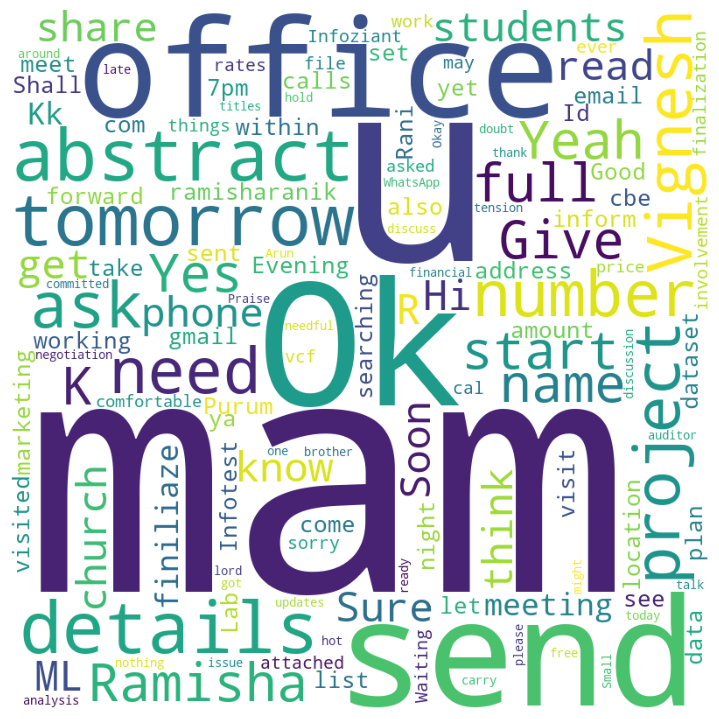

Successfully created


In [26]:
#23.GENERATING A WORD CLOUD

comment_words = []
# comment_words → Variable storing an empty list to collect all chat text

stoplist = stopwords.words('english')
# stoplist → Variable storing the list of common English stopwords
# stopwords.words('english') → Returns NLTK's built-in English stopword list

stoplist.extend(['omitted', 'voice','missed','call','video','deleted','media','message'])
# stoplist.extend → Adds additional items to the existing stoplist
# [...] → Custom WhatsApp-related words to exclude (e.g. system messages like "media omitted")

wordclouds = "This function saves image"
# wordclouds → Variable storing a label string (used only as a comment/marker, has no functional effect)

dataset.index = range(dataset.shape[0])
# dataset.index → Resets the row index of dataset
# range(dataset.shape[0]) → Creates a new sequential index from 0 to the total number of rows

for i in range(1,len(dataset)):
# for → Python keyword that starts a loop
# i → Loop variable representing each row index
# range(1,len(dataset)) → Loops from row 1 to the last row (skipping row 0)
# : → Marks the start of the loop's code block

    comment_words.append(dataset['Chat'][i])
    # comment_words.append → Adds an item to the comment_words list
    # dataset['Chat'][i] → The chat text at row i

    vv = " ".join(comment_words)
    # vv → Variable storing all collected chat text combined into one string
    # " ".join(comment_words) → Joins all list items into a single string, separated by spaces

    wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stoplist,
                min_font_size = 10).generate(vv)
    # wordcloud → Variable storing the generated word cloud object
    # WordCloud → Class that creates a word cloud visualization
    # width=800, height=800 → Sets the image dimensions in pixels
    # background_color='white' → Sets the background color of the word cloud
    # stopwords=stoplist → Excludes the specified common/unwanted words
    # min_font_size=10 → Sets the smallest font size used for less frequent words
    # .generate(vv) → Builds the word cloud from the combined chat text

plt.figure(figsize = (9, 7), facecolor = None)
# plt.figure → Creates a new matplotlib figure
# figsize=(9, 7) → Sets the figure size in inches
# facecolor=None → No specific background color set for the figure

plt.imshow(wordcloud)
# plt.imshow → Displays the word cloud image on the figure

plt.axis("off")
# plt.axis("off") → Hides the axis lines and labels for a cleaner image

plt.tight_layout(pad = 0)
# plt.tight_layout → Adjusts spacing to prevent overlap
# pad=0 → Removes extra padding around the image

plt.savefig('wordcloud.PNG')
# plt.savefig → Saves the current figure as an image file
# 'wordcloud.PNG' → File name for the saved word cloud image

plt.show()
# plt.show → Displays the plot in the notebook output

print("Successfully created")
# print → Built-in function that displays output
# "Successfully created" → Confirmation message shown after the word cloud is generated and saved

wordcloudss = "This function saves image"
# wordcloudss → Variable storing a label string (used only as a comment/marker, has no functional effect)

# This cell builds a word cloud from all chat messages (excluding stopwords and WhatsApp system terms), then displays and saves it as wordcloud.PNG.